# Analisi esplorativa e Feature Engineering del dataset di magazzino

In questo notebook viene analizzato il dataset precedentemente pulito.

L'obiettivo è comprendere la struttura dei dati, individuare informazioni utili per la gestione del magazzino, creare nuove variabili e rappresentare i principali risultati attraverso grafici.

In [1]:
# Importazione delle librerie necessarie per l'analisi dei dati e la creazione dei grafici

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


In [2]:
# Verifica della presenza del dataset pulito

file_input = Path("Dataset_pulito.csv")

print("Percorso del file:")
print(file_input.resolve())

print("\nIl file esiste:")
print(file_input.exists())


Percorso del file:
C:\Users\mace\OneDrive\python\installazione1\project work\Analisi dati di magazzino\Dataset_pulito.csv

Il file esiste:
True


In [3]:
# Caricamento del dataset pulito

df = pd.read_csv(
    file_input,
    parse_dates=[
        "Date_Received",
        "Last_Order_Date",
        "Expiration_Date"
    ]
)

print("Dataset caricato correttamente.")
print("Righe:", df.shape[0])
print("Colonne:", df.shape[1])


Dataset caricato correttamente.
Righe: 990
Colonne: 16


In [4]:
# Verifica del dataset caricato

print("Dimensioni del dataset:")
print(df.shape)

print("\nPrime 5 righe:")
display(df.head())

print("\nTipi di dato:")
print(df.dtypes)


Dimensioni del dataset:
(990, 16)

Prime 5 righe:


,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,2024-08-16,2024-06-29,2024-09-19,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,2024-11-01,2024-05-29,2024-05-08,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,2024-08-03,2024-06-10,2024-09-22,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,2024-12-08,2025-02-19,2024-04-17,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,2024-07-03,2024-10-11,2024-10-05,15068 Scoville Court,62,25,Backordered



Tipi di dato:
Product_ID                            str
Product_Name                          str
Category                              str
Supplier_ID                           str
Supplier_Name                         str
Stock_Quantity                      int64
Reorder_Level                       int64
Reorder_Quantity                    int64
Unit_Price                        float64
Date_Received              datetime64[us]
Last_Order_Date            datetime64[us]
Expiration_Date            datetime64[us]
Warehouse_Location                    str
Sales_Volume                        int64
Inventory_Turnover_Rate             int64
Status                                str
dtype: object


### Distribuzione dei prezzi unitari

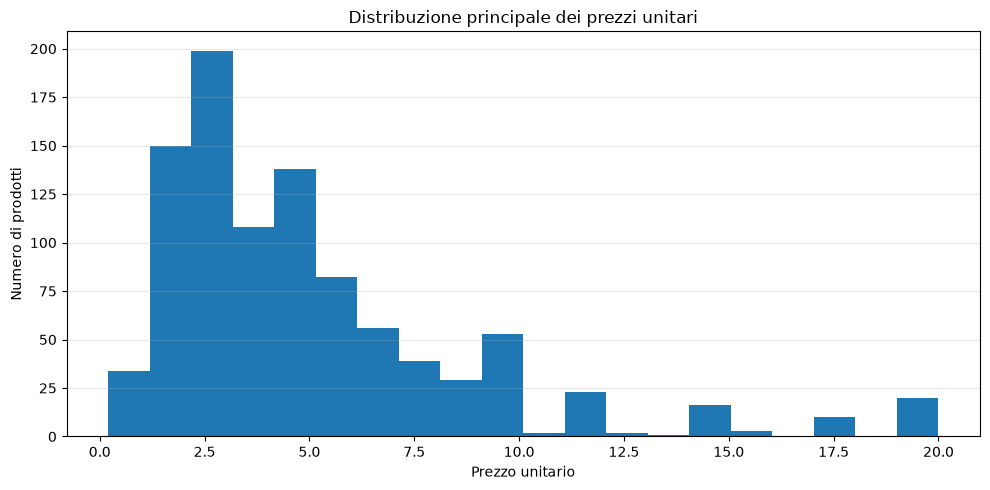

In [5]:
# Creazione dell'istogramma dei prezzi unitari fino al valore 20

prezzi_fino_a_20 = df.loc[
    df["Unit_Price"] <= 20,
    "Unit_Price"
]

plt.figure(figsize=(10, 5))

plt.hist(
    prezzi_fino_a_20,
    bins=20
)

plt.title("Distribuzione principale dei prezzi unitari")
plt.xlabel("Prezzo unitario")
plt.ylabel("Numero di prodotti")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Distribuzione dei prodotti per categoria

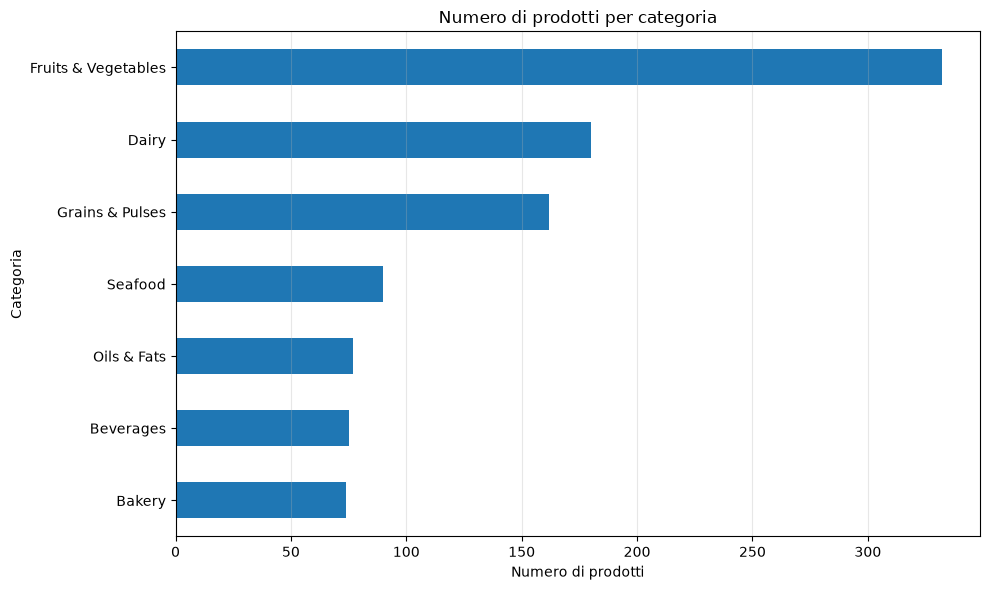

In [6]:
# Conteggio del numero di prodotti per categoria

conteggio_categorie = (
    df["Category"]
    .value_counts()
    .sort_values(ascending=True)
)

# Creazione del grafico a barre orizzontali

plt.figure(figsize=(10, 6))

conteggio_categorie.plot(
    kind="barh"
)

plt.title("Numero di prodotti per categoria")
plt.xlabel("Numero di prodotti")
plt.ylabel("Categoria")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Distribuzione dei prodotti per stato



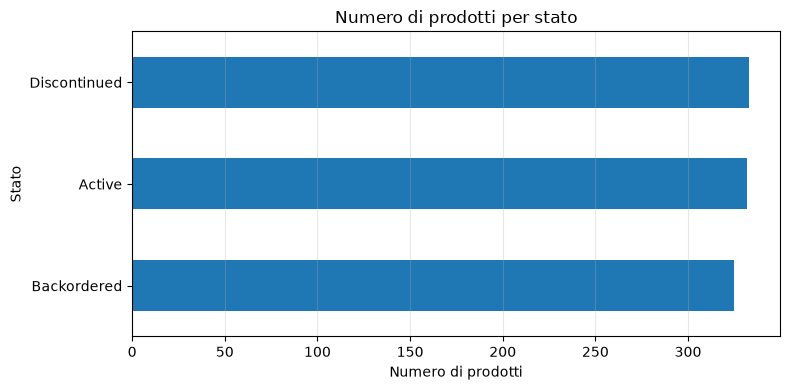

In [7]:
# Conteggio del numero di prodotti per stato

conteggio_status = (
    df["Status"]
    .value_counts()
    .sort_values(ascending=True)
)

# Creazione del grafico a barre orizzontali

plt.figure(figsize=(8, 4))

conteggio_status.plot(
    kind="barh"
)

plt.title("Numero di prodotti per stato")
plt.xlabel("Numero di prodotti")
plt.ylabel("Stato")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Distribuzione dei prodotti per location

In [8]:
# Verifica delle posizioni di magazzino complete ripetute

numero_righe = len(df)
numero_posizioni = df["Warehouse_Location"].nunique()

conteggio_posizioni = df["Warehouse_Location"].value_counts()

posizioni_ripetute = conteggio_posizioni[
    conteggio_posizioni > 1
]

percentuale_uniche = numero_posizioni / numero_righe * 100

print("Numero totale di righe:", numero_righe)
print("Numero di posizioni distinte:", numero_posizioni)
print("Percentuale di posizioni uniche:", round(percentuale_uniche, 2), "%")


Numero totale di righe: 990
Numero di posizioni distinte: 990
Percentuale di posizioni uniche: 100.0 %


### Osservazione sulla variabile Warehouse_Location

La colonna `Warehouse_Location` contiene un indirizzo diverso per ogni osservazione.

E' insolito per un normale posizionamento di magazzino, dove ci si aspetterebbe la ripetizione di corsie, scaffali, reparti o sedi.

Si sospetta che i dati non siano realistici

# Analisi dello stato delle scorte

Lo stato delle scorte viene determinato confrontando la quantità disponibile con il livello di riordino.

I prodotti vengono classificati in tre gruppi:

- **Scorta sufficiente**: quantità superiore al livello di riordino;
- **Sulla soglia**: quantità uguale al livello di riordino;
- **Da riordinare**: quantità inferiore al livello di riordino.

In [9]:
# Creazione di un'etichetta univoca per identificare i prodotti nei grafici

df["Product_Label"] = (
    df["Product_Name"].astype(str)
    + " | "
    + df["Product_ID"].astype(str)
)

display(
    df[
        [
            "Product_ID",
            "Product_Name",
            "Product_Label"
        ]
    ].head()
)

,Product_ID,Product_Name,Product_Label
0,29-205-1132,Sushi Rice,Sushi Rice | 29-205-1132
1,40-681-9981,Arabica Coffee,Arabica Coffee | 40-681-9981
2,06-955-3428,Black Rice,Black Rice | 06-955-3428
3,71-594-6552,Long Grain Rice,Long Grain Rice | 71-594-6552
4,57-437-1828,Plum,Plum | 57-437-1828


In [10]:
# Individuazione dei prodotti che hanno raggiunto il livello di riordino

prodotti_da_riordinare = df[
    df["Stock_Quantity"] <= df["Reorder_Level"]
].copy()

# Calcolo del numero e della percentuale di prodotti da riordinare o sulla soglia

numero_prodotti_da_riordinare = len(prodotti_da_riordinare)

percentuale_da_riordinare = (
    numero_prodotti_da_riordinare / len(df)
) * 100

# Visualizzazione dei risultati

print("Totale prodotti:", len(df))
print(
    "Prodotti da riordinare o sulla soglia:",
    numero_prodotti_da_riordinare
)
print(
    "Percentuale:",
    round(percentuale_da_riordinare, 2),
    "%"
)

Totale prodotti: 990
Prodotti da riordinare o sulla soglia: 465
Percentuale: 46.97 %


In [11]:
# Creazione dello stato della fornitura e della distanza dal livello di riordino

condizioni = [
    df["Stock_Quantity"] < df["Reorder_Level"],
    df["Stock_Quantity"] == df["Reorder_Level"]
]

stati = [
    "Da riordinare",
    "Sulla soglia"
]

df["Supply_Status"] = np.select(
    condizioni,
    stati,
    default="Scorta sufficiente"
)

df["Stock_Gap"] = (
    df["Stock_Quantity"] - df["Reorder_Level"]
)

display(
    df[
        [
            "Product_ID",
            "Product_Name",
            "Stock_Quantity",
            "Reorder_Level",
            "Stock_Gap",
            "Supply_Status"
        ]
    ].head()
)

,Product_ID,Product_Name,Stock_Quantity,Reorder_Level,Stock_Gap,Supply_Status
0,29-205-1132,Sushi Rice,22,72,-50,Da riordinare
1,40-681-9981,Arabica Coffee,45,77,-32,Da riordinare
2,06-955-3428,Black Rice,30,38,-8,Da riordinare
3,71-594-6552,Long Grain Rice,12,59,-47,Da riordinare
4,57-437-1828,Plum,37,30,7,Scorta sufficiente


In [12]:
# Selezione dei primi 20 prodotti maggiormente sotto il livello di riordino

primi_20_da_riordinare = (
    df[df["Supply_Status"] == "Da riordinare"]
    .sort_values(
        by="Stock_Gap",
        ascending=True
    )
    .head(20)
    .copy()
)

display(
    primi_20_da_riordinare[
        [
            "Product_ID",
            "Product_Name",
            "Category",
            "Stock_Quantity",
            "Reorder_Level",
            "Reorder_Quantity",
            "Stock_Gap",
            "Supply_Status"
        ]
    ]
)

,Product_ID,Product_Name,Category,Stock_Quantity,Reorder_Level,Reorder_Quantity,Stock_Gap,Supply_Status
125,70-149-6756,Heavy Cream,Dairy,14,99,97,-85,Da riordinare
501,21-013-3508,Cabbage,Fruits & Vegetables,12,95,49,-83,Da riordinare
851,79-884-8810,Cucumber,Fruits & Vegetables,12,93,29,-81,Da riordinare
345,67-512-9754,Egg (Turkey),Dairy,19,100,83,-81,Da riordinare
895,57-167-0669,Haddock,Seafood,19,99,78,-80,Da riordinare
285,59-857-6577,Evaporated Milk,Dairy,23,100,77,-77,Da riordinare
618,83-727-0814,Basmati Rice,Grains & Pulses,11,87,64,-76,Da riordinare
180,00-357-2313,Avocado Oil,Oils & Fats,10,86,23,-76,Da riordinare
854,39-913-2999,Evaporated Milk,Dairy,23,99,97,-76,Da riordinare
780,88-807-8431,Haddock,Seafood,11,87,43,-76,Da riordinare


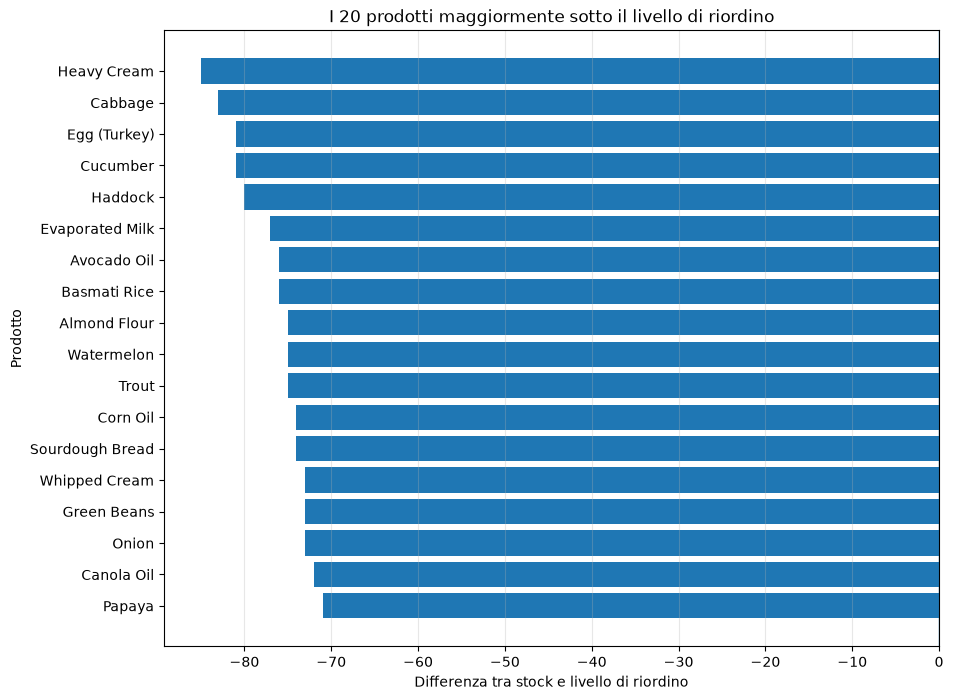

In [13]:
# Grafico dei 20 prodotti maggiormente sotto il livello di riordino

prodotti_critici_grafico = (
    primi_20_da_riordinare
    .sort_values(
        by="Stock_Gap",
        ascending=False
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    prodotti_critici_grafico["Product_Name"],
    prodotti_critici_grafico["Stock_Gap"]
)

plt.title("I 20 prodotti maggiormente sotto il livello di riordino")
plt.xlabel("Differenza tra stock e livello di riordino")
plt.ylabel("Prodotto")

plt.axvline(
    x=0,
    linewidth=1
)

plt.grid(axis="x", alpha=0.3)

plt.show()

In [14]:
# Conteggio dei prodotti per stato della fornitura

conteggio_stato_fornitura = (
    df["Supply_Status"]
    .value_counts()
)

display(conteggio_stato_fornitura)

Supply_Status
Scorta sufficiente    525
Da riordinare         455
Sulla soglia           10
Name: count, dtype: int64

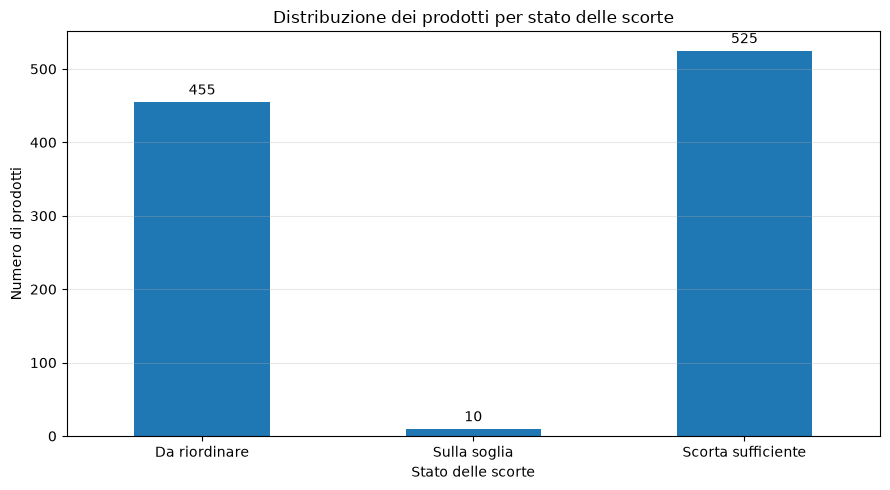

In [15]:
# Grafico del numero di prodotti per stato della fornitura

ordine_stati = [
    "Da riordinare",
    "Sulla soglia",
    "Scorta sufficiente"
]

conteggio_stato_fornitura = (
    df["Supply_Status"]
    .value_counts()
    .reindex(
        ordine_stati,
        fill_value=0
    )
)

plt.figure(figsize=(9, 5))

barre = conteggio_stato_fornitura.plot(
    kind="bar"
)

plt.title("Distribuzione dei prodotti per stato delle scorte")
plt.xlabel("Stato delle scorte")
plt.ylabel("Numero di prodotti")

plt.xticks(rotation=0)
plt.bar_label(
    barre.containers[0],
    fmt="%.0f",
    padding=3
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Interpretazione

Il confronto tra `Stock_Quantity` e `Reorder_Level` ha permesso di classificare ogni prodotto in base allo stato delle scorte.

I prodotti con stato **Da riordinare** presentano una quantità disponibile inferiore al livello di riordino. La colonna `Stock_Gap` permette di ordinare questi prodotti in base alla distanza dalla soglia: i valori più negativi identificano le situazioni potenzialmente più urgenti.

La classificazione indica la necessità di valutare un riordino, ma non conferma che un ordine sia già stato inviato.

### Valore economico dello stock

La variabile `Inventory_Value` stima il valore dello stock disponibile per ciascun prodotto, moltiplicando la quantità presente per il prezzo unitario.

Il risultato permette di individuare i prodotti che rappresentano il maggiore valore economico presente in magazzino.

La misura costituisce una stima, perché il dataset non chiarisce se `Unit_Price` rappresenti il costo di acquisto oppure il prezzo di vendita.

In [16]:
# Calcolo del valore economico dello stock disponibile

df["Inventory_Value"] = (
    df["Stock_Quantity"] * df["Unit_Price"]
)

# Selezione dei 10 prodotti con il maggiore valore di stock

top_10_inventory_value = (
    df.sort_values(
        by="Inventory_Value",
        ascending=False
    )
    .head(10)
    .copy()
)

# Visualizzazione dei risultati

display(
    top_10_inventory_value[
        [
            "Product_ID",
            "Product_Name",
            "Category",
            "Stock_Quantity",
            "Unit_Price",
            "Inventory_Value"
        ]
    ]
)

,Product_ID,Product_Name,Category,Stock_Quantity,Unit_Price,Inventory_Value
113,87-698-0944,Banana,Fruits & Vegetables,56,98.43,5512.08
325,48-957-8596,Banana,Fruits & Vegetables,95,53.82,5112.90
685,10-378-9729,Cabbage,Fruits & Vegetables,69,66.55,4591.95
208,68-734-1585,Greek Yogurt,Fruits & Vegetables,62,51.17,3172.54
66,20-225-3930,White Tea,Beverages,99,25.00,2475.00
33,79-136-9840,Herbal Tea,Beverages,77,30.00,2310.00
532,86-482-6451,White Tea,Beverages,91,25.00,2275.00
710,57-394-4703,White Tea,Beverages,81,25.00,2025.00
440,11-155-7826,Arabica Coffee,Beverages,98,20.00,1960.00
229,76-954-1442,Arabica Coffee,Beverages,97,20.00,1940.00


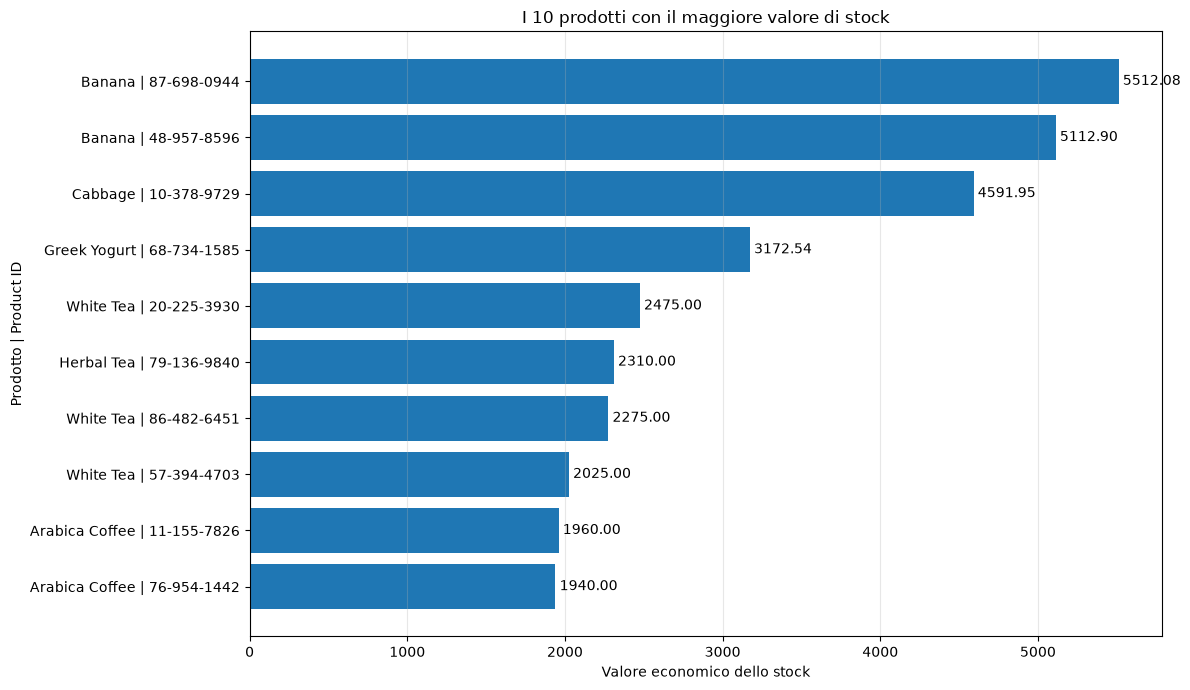

In [17]:
# Grafico dei 10 prodotti con il maggiore valore economico dello stock

dati_grafico_inventory = (
    top_10_inventory_value
    .sort_values(
        by="Inventory_Value",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

barre = plt.barh(
    dati_grafico_inventory["Product_Label"],
    dati_grafico_inventory["Inventory_Value"]
)

plt.title("I 10 prodotti con il maggiore valore di stock")
plt.xlabel("Valore economico dello stock")
plt.ylabel("Prodotto | Product ID")

plt.bar_label(
    barre,
    fmt="%.2f",
    padding=3
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Costo stimato del riordino

La variabile `Estimated_Reorder_Cost` stima il valore economico della quantità prevista per il riordino.

Il calcolo utilizza la quantità indicata in `Reorder_Quantity` e il prezzo unitario del prodotto.

La misura costituisce una stima e non necessariamente il costo effettivamente sostenuto presso il fornitore.

In [18]:
# Calcolo del costo stimato della quantità prevista per il riordino

df["Estimated_Reorder_Cost"] = (
    df["Reorder_Quantity"] * df["Unit_Price"]
)

# Selezione dei prodotti che richiedono un riordino

prodotti_effettivamente_da_riordinare = df[
    df["Supply_Status"].isin(
        [
            "Da riordinare",
            "Sulla soglia"
        ]
    )
].copy()

# Selezione dei 10 riordini con il maggiore costo stimato

top_10_reorder_cost = (
    prodotti_effettivamente_da_riordinare
    .sort_values(
        by="Estimated_Reorder_Cost",
        ascending=False
    )
    .head(10)
    .copy()
)

# Visualizzazione dei risultati

display(
    top_10_reorder_cost[
        [
            "Product_ID",
            "Product_Name",
            "Stock_Quantity",
            "Reorder_Level",
            "Reorder_Quantity",
            "Unit_Price",
            "Estimated_Reorder_Cost",
            "Supply_Status"
        ]
    ]
)

,Product_ID,Product_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Estimated_Reorder_Cost,Supply_Status
161,80-374-5711,Herbal Tea,48,77,81,31.0,2511.0,Da riordinare
210,65-282-0419,White Tea,50,100,91,25.5,2320.5,Da riordinare
134,87-791-5803,Tuna,25,44,96,18.0,1728.0,Da riordinare
138,44-538-3366,Tuna,58,77,96,18.0,1728.0,Da riordinare
18,48-414-6162,Arabica Coffee,55,93,84,20.0,1680.0,Da riordinare
349,93-166-3169,White Tea,58,81,66,25.0,1650.0,Da riordinare
608,73-010-8323,Tuna,16,34,89,18.0,1602.0,Da riordinare
278,00-119-8780,Halibut,40,81,78,20.0,1560.0,Da riordinare
757,48-427-0551,Arabica Coffee,13,55,77,20.0,1540.0,Da riordinare
188,14-681-7035,White Tea,36,90,57,25.0,1425.0,Da riordinare


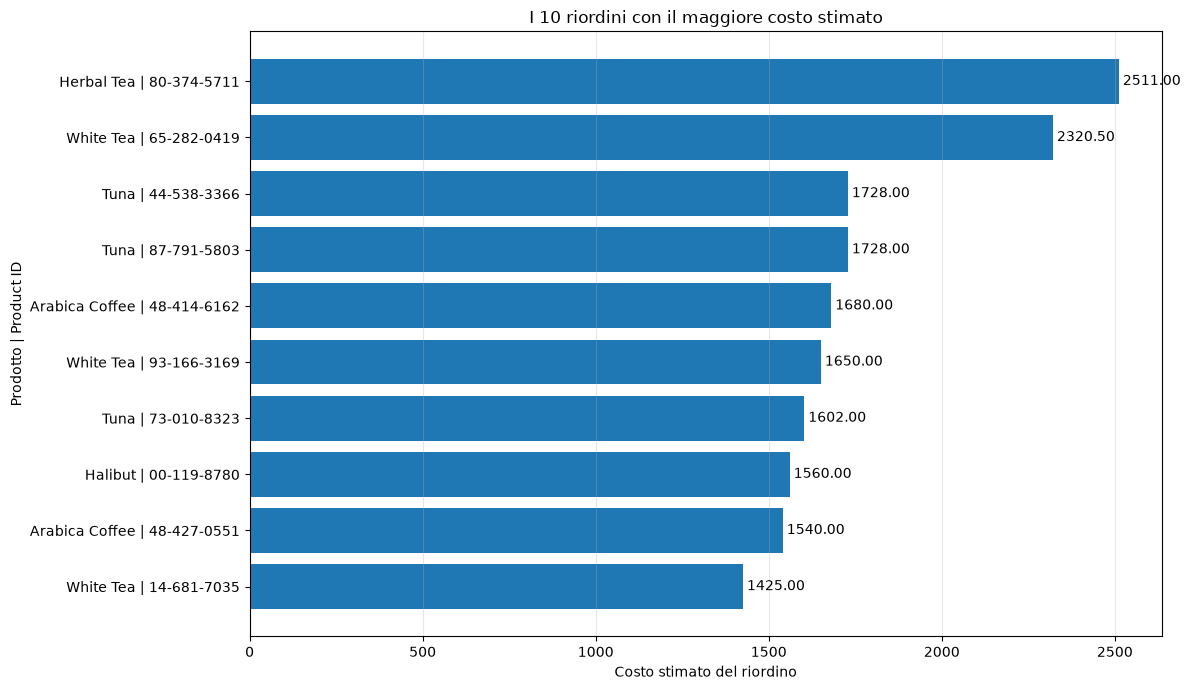

In [19]:
# Grafico dei 10 riordini con il maggiore costo stimato

dati_grafico_reorder_cost = (
    top_10_reorder_cost
    .sort_values(
        by="Estimated_Reorder_Cost",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

barre = plt.barh(
    dati_grafico_reorder_cost["Product_Label"],
    dati_grafico_reorder_cost["Estimated_Reorder_Cost"]
)

plt.title("I 10 riordini con il maggiore costo stimato")
plt.xlabel("Costo stimato del riordino")
plt.ylabel("Prodotto | Product ID")

plt.bar_label(
    barre,
    fmt="%.2f",
    padding=3
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Unità mancanti rispetto al livello di riordino

La variabile `Units_To_Reorder_Level` indica quante unità mancano per riportare lo stock almeno al livello di riordino.

I prodotti che non sono sotto soglia ricevono valore zero.

In [20]:
# Calcolo delle unità mancanti rispetto al livello di riordino

df["Units_To_Reorder_Level"] = (
    df["Reorder_Level"] - df["Stock_Quantity"]
).clip(lower=0)

# Selezione dei 10 prodotti con la maggiore carenza di unità

top_10_units_missing = (
    df[df["Units_To_Reorder_Level"] > 0]
    .sort_values(
        by="Units_To_Reorder_Level",
        ascending=False
    )
    .head(10)
    .copy()
)

# Visualizzazione dei risultati

display(
    top_10_units_missing[
        [
            "Product_ID",
            "Product_Name",
            "Category",
            "Stock_Quantity",
            "Reorder_Level",
            "Units_To_Reorder_Level",
            "Supply_Status"
        ]
    ]
)

,Product_ID,Product_Name,Category,Stock_Quantity,Reorder_Level,Units_To_Reorder_Level,Supply_Status
125,70-149-6756,Heavy Cream,Dairy,14,99,85,Da riordinare
501,21-013-3508,Cabbage,Fruits & Vegetables,12,95,83,Da riordinare
851,79-884-8810,Cucumber,Fruits & Vegetables,12,93,81,Da riordinare
345,67-512-9754,Egg (Turkey),Dairy,19,100,81,Da riordinare
895,57-167-0669,Haddock,Seafood,19,99,80,Da riordinare
285,59-857-6577,Evaporated Milk,Dairy,23,100,77,Da riordinare
618,83-727-0814,Basmati Rice,Grains & Pulses,11,87,76,Da riordinare
180,00-357-2313,Avocado Oil,Oils & Fats,10,86,76,Da riordinare
780,88-807-8431,Haddock,Seafood,11,87,76,Da riordinare
854,39-913-2999,Evaporated Milk,Dairy,23,99,76,Da riordinare


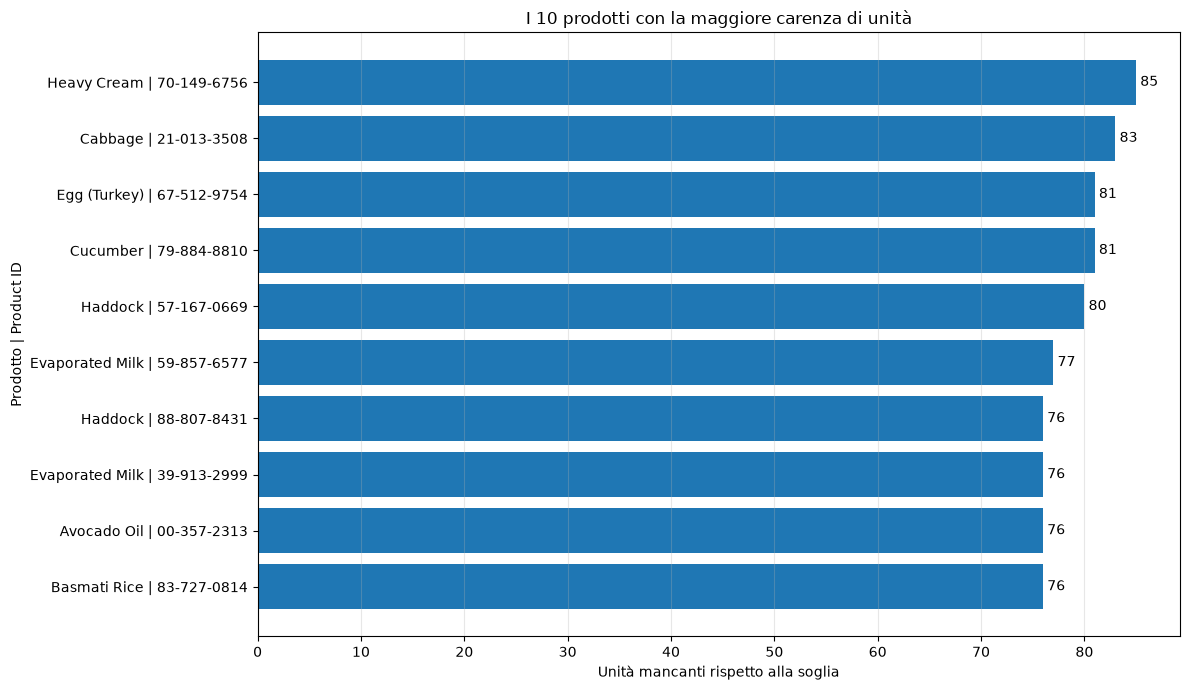

In [21]:
# Grafico dei 10 prodotti con la maggiore carenza di unità

dati_grafico_units_missing = (
    top_10_units_missing
    .sort_values(
        by="Units_To_Reorder_Level",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

barre = plt.barh(
    dati_grafico_units_missing["Product_Label"],
    dati_grafico_units_missing["Units_To_Reorder_Level"]
)

plt.title("I 10 prodotti con la maggiore carenza di unità")
plt.xlabel("Unità mancanti rispetto alla soglia")
plt.ylabel("Prodotto | Product ID")

plt.bar_label(
    barre,
    fmt="%.0f",
    padding=3
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Rapporto tra stock e livello di riordino

La variabile `Stock_Reorder_Ratio` confronta la quantità disponibile con il livello di riordino.

- un valore inferiore a `1` indica che il prodotto è sotto soglia;
- un valore uguale a `1` indica che il prodotto si trova sulla soglia;
- un valore superiore a `1` indica che lo stock è sopra soglia.

In [22]:
# Calcolo del rapporto tra stock disponibile e livello di riordino

df["Stock_Reorder_Ratio"] = (
    df["Stock_Quantity"] / df["Reorder_Level"]
)

# Selezione dei 20 prodotti con il rapporto più basso

top_10_lowest_ratio = (
    df.sort_values(
        by="Stock_Reorder_Ratio",
        ascending=True
    )
    .head(20)
    .copy()
)

# Visualizzazione dei risultati

display(
    top_10_lowest_ratio[
        [
            "Product_ID",
            "Product_Name",
            "Category",
            "Stock_Quantity",
            "Reorder_Level",
            "Stock_Reorder_Ratio",
            "Supply_Status"
        ]
    ].round(
        {
            "Stock_Reorder_Ratio": 2
        }
    )
)

,Product_ID,Product_Name,Category,Stock_Quantity,Reorder_Level,Stock_Reorder_Ratio,Supply_Status
180,00-357-2313,Avocado Oil,Oils & Fats,10,86,0.12,Da riordinare
501,21-013-3508,Cabbage,Fruits & Vegetables,12,95,0.13,Da riordinare
780,88-807-8431,Haddock,Seafood,11,87,0.13,Da riordinare
618,83-727-0814,Basmati Rice,Grains & Pulses,11,87,0.13,Da riordinare
851,79-884-8810,Cucumber,Fruits & Vegetables,12,93,0.13,Da riordinare
148,73-561-2867,Sourdough Bread,Bakery,12,86,0.14,Da riordinare
125,70-149-6756,Heavy Cream,Dairy,14,99,0.14,Da riordinare
837,58-946-5152,Bread Flour,Grains & Pulses,11,77,0.14,Da riordinare
665,03-441-4252,Yogurt,Dairy,12,83,0.14,Da riordinare
104,62-509-0666,Almond Flour,Grains & Pulses,13,88,0.15,Da riordinare


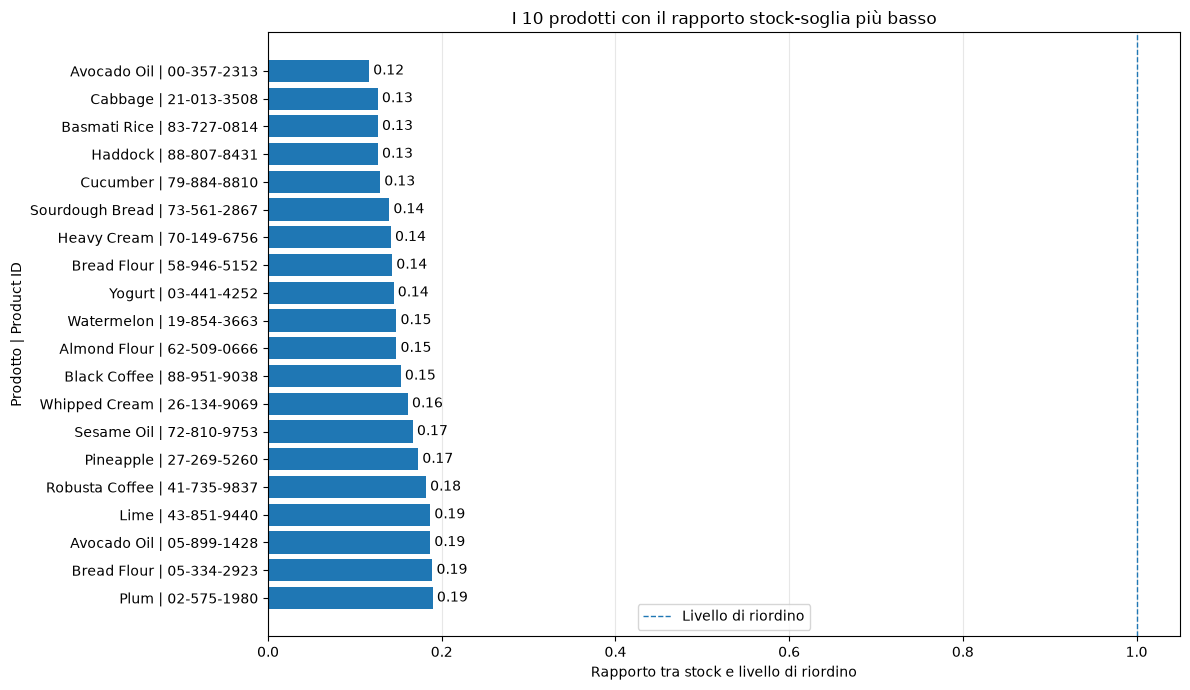

In [23]:
# Grafico dei 10 prodotti con il rapporto stock-soglia più basso

dati_grafico_lowest_ratio = (
    top_10_lowest_ratio
    .sort_values(
        by="Stock_Reorder_Ratio",
        ascending=False
    )
)

plt.figure(figsize=(12, 7))

barre = plt.barh(
    dati_grafico_lowest_ratio["Product_Label"],
    dati_grafico_lowest_ratio["Stock_Reorder_Ratio"]
)

plt.axvline(
    x=1,
    linewidth=1,
    linestyle="--",
    label="Livello di riordino"
)

plt.title("I 10 prodotti con il rapporto stock-soglia più basso")
plt.xlabel("Rapporto tra stock e livello di riordino")
plt.ylabel("Prodotto | Product ID")

plt.bar_label(
    barre,
    fmt="%.2f",
    padding=3
)

plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

In [24]:
# Controllo finale delle variabili create durante la feature engineering

nuove_colonne = [
    "Product_Label",
    "Supply_Status",
    "Stock_Gap",
    "Inventory_Value",
    "Estimated_Reorder_Cost",
    "Units_To_Reorder_Level",
    "Stock_Reorder_Ratio"
]

display(
    df[
        [
            "Product_ID",
            "Product_Name"
        ] + nuove_colonne
    ].head(10)
)

,Product_ID,Product_Name,Product_Label,Supply_Status,Stock_Gap,Inventory_Value,Estimated_Reorder_Cost,Units_To_Reorder_Level,Stock_Reorder_Ratio
0,29-205-1132,Sushi Rice,Sushi Rice | 29-205-1132,Da riordinare,-50,99.00,315.0,50,0.305556
1,40-681-9981,Arabica Coffee,Arabica Coffee | 40-681-9981,Da riordinare,-32,900.00,40.0,32,0.584416
2,06-955-3428,Black Rice,Black Rice | 06-955-3428,Da riordinare,-8,180.00,498.0,8,0.789474
3,71-594-6552,Long Grain Rice,Long Grain Rice | 71-594-6552,Da riordinare,-47,18.00,93.0,47,0.203390
4,57-437-1828,Plum,Plum | 57-437-1828,Scorta sufficiente,7,148.00,296.0,0,1.233333
5,21-120-6238,All-Purpose Flour,All-Purpose Flour | 21-120-6238,Scorta sufficiente,22,96.25,24.5,0,1.666667
6,71-516-1996,Corn Oil,Corn Oil | 71-516-1996,Scorta sufficiente,44,240.00,40.0,0,1.846154
7,39-629-5554,Egg (Goose),Egg (Goose) | 39-629-5554,Da riordinare,-46,110.00,42.5,46,0.488889
8,66-268-8345,Greek Yogurt,Greek Yogurt | 66-268-8345,Scorta sufficiente,7,273.00,33.0,0,1.083333
9,46-452-9419,Egg (Duck),Egg (Duck) | 46-452-9419,Scorta sufficiente,33,43.00,15.0,0,4.300000


## Analisi dei fornitori

L'analisi aggrega i prodotti per `Supplier_Name` per valutare:

- il numero di prodotti associati a ciascun fornitore;
- il valore economico dello stock;
- il numero di prodotti da riordinare;
- il numero di prodotti con stato `Backordered`;
- il costo stimato complessivo dei riordini.

Viene inoltre controllato il numero di `Supplier_ID` distinti associati a ogni nome, così da documentare correttamente la struttura del dataset.

In [25]:
# Controllo del numero di nomi e identificativi distinti dei fornitori

numero_supplier_id = df["Supplier_ID"].nunique()
numero_supplier_name = df["Supplier_Name"].nunique()

print("Numero totale di righe:", len(df))
print("Supplier_ID distinti:", numero_supplier_id)
print("Supplier_Name distinti:", numero_supplier_name)

# Conteggio degli identificativi distinti associati a ogni nome fornitore

id_per_fornitore = (
    df.groupby("Supplier_Name")["Supplier_ID"]
    .nunique()
    .sort_values(ascending=False)
)

display(
    id_per_fornitore
    .head(10)
    .rename("Supplier_ID distinti")
)

Numero totale di righe: 990
Supplier_ID distinti: 990
Supplier_Name distinti: 350


Supplier_Name
Katz           12
Meevee         10
Quatz           9
Twitterwire     7
Quinu           7
Eimbee          7
Photobug        7
Babblestorm     7
Vinder          7
Gigashots       6
Name: Supplier_ID distinti, dtype: int64

In [27]:
# Creazione delle nuove colonne per l'analisi dei fornitori

df["Reorder_Needed_Flag"] = df["Supply_Status"].isin(
    ["Da riordinare", "Sulla soglia"]
).astype(int)

#Il flag può valere 0 o 1, de vale 1 il costo viene mtantenuto, se vale 0 diventa 0

df["Reorder_Cost_Required"] = (
    df["Estimated_Reorder_Cost"] * df["Reorder_Needed_Flag"]
)

df["Backordered_Flag"] = (
    df["Status"] == "Backordered"
).astype(int)

# Selezione delle colonne da visualizzare

colonne_fornitori = [
    "Product_ID",
    "Product_Name",
    "Supplier_Name",
    "Supply_Status",
    "Reorder_Needed_Flag",
    "Estimated_Reorder_Cost",
    "Reorder_Cost_Required",
    "Status",
    "Backordered_Flag"
]

display(df[colonne_fornitori].head(10))

,Product_ID,Product_Name,Supplier_Name,Supply_Status,Reorder_Needed_Flag,Estimated_Reorder_Cost,Reorder_Cost_Required,Status,Backordered_Flag
0,29-205-1132,Sushi Rice,Jaxnation,Da riordinare,1,315.0,315.0,Discontinued,0
1,40-681-9981,Arabica Coffee,Feedmix,Da riordinare,1,40.0,40.0,Discontinued,0
2,06-955-3428,Black Rice,Vinder,Da riordinare,1,498.0,498.0,Backordered,1
3,71-594-6552,Long Grain Rice,Brightbean,Da riordinare,1,93.0,93.0,Active,0
4,57-437-1828,Plum,Topicstorm,Scorta sufficiente,0,296.0,0.0,Backordered,1
5,21-120-6238,All-Purpose Flour,Dabjam,Scorta sufficiente,0,24.5,0.0,Discontinued,0
6,71-516-1996,Corn Oil,Tagfeed,Scorta sufficiente,0,40.0,0.0,Active,0
7,39-629-5554,Egg (Goose),Muxo,Da riordinare,1,42.5,42.5,Discontinued,0
8,66-268-8345,Greek Yogurt,Thoughtstorm,Scorta sufficiente,0,33.0,0.0,Active,0
9,46-452-9419,Egg (Duck),Wordify,Scorta sufficiente,0,15.0,0.0,Active,0


In [33]:
# Creazione del riepilogo delle principali statistiche per fornitore

riepilogo_fornitori = df.groupby("Supplier_Name").agg(
    Numero_Prodotti=("Product_ID", "count"),
    Prodotti_Da_Riordinare=("Reorder_Needed_Flag", "sum"),
    Prodotti_Backordered=("Backordered_Flag", "sum"),
    Valore_Stock=("Inventory_Value", "sum"),
    Costo_Riordino_Stimato=("Reorder_Cost_Required", "sum")
).reset_index()

# Ordinamento in base al numero di prodotti da riordinare

riepilogo_fornitori = riepilogo_fornitori.sort_values(
    by="Prodotti_Da_Riordinare",
    ascending=False
)

# Visualizzazione dei primi 10 fornitori

display(riepilogo_fornitori.head(20))

,Supplier_Name,Numero_Prodotti,Prodotti_Da_Riordinare,Prodotti_Backordered,Valore_Stock,Costo_Riordino_Stimato
165,Meevee,10,6,8,1943.35,977.7
230,Shuffledrive,6,5,1,1726.50,1896.0
84,Eimbee,7,5,3,1837.00,385.2
15,BlogXS,5,5,2,1145.00,1888.8
274,Topdrive,4,4,0,511.35,1564.3
298,Vinder,7,4,4,6285.08,972.0
57,Dazzlesphere,4,4,2,744.00,1170.5
103,Flipopia,6,4,1,1963.50,801.0
130,Jayo,4,4,2,1289.10,1936.8
138,Katz,12,4,7,3439.25,858.0


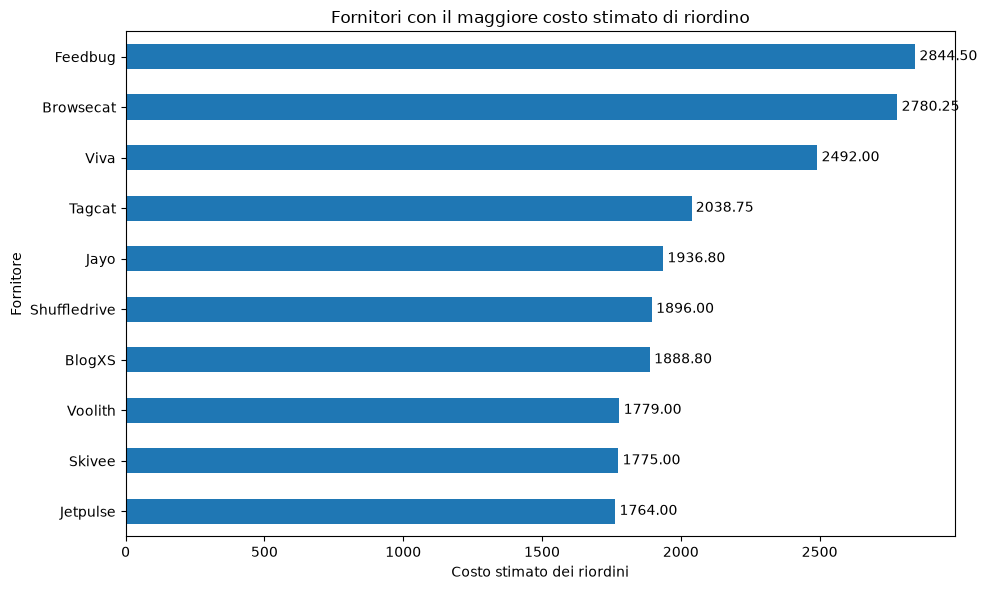

In [47]:
# Grafico dei 10 fornitori con il maggiore costo stimato di riordino

top_10_fornitori = (
    df.groupby("Supplier_Name")["Reorder_Cost_Required"]
    .sum()
    .nlargest(10)
    .sort_values()
)

ax = top_10_fornitori.plot(
    kind="barh",
    figsize=(10, 6)
)

# Visualizzazione del valore accanto a ogni barra

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.title("Fornitori con il maggiore costo stimato di riordino")
plt.xlabel("Costo stimato dei riordini")
plt.ylabel("Fornitore")
plt.tight_layout()

plt.show()

### Considerazioni

Il dataset contiene 350 nomi di fornitori distinti, ma 990 `Supplier_ID` differenti, uno per ogni riga. Per questo motivo l'analisi viene effettuata utilizzando `Supplier_Name`, che rappresenta l'unico campo disponibile per raggruppare più prodotti sotto lo stesso fornitore.

Complessivamente, 465 prodotti su 990, pari a circa il 47%, risultano da riordinare o sulla soglia. In particolare, 455 prodotti sono sotto il livello di riordino e 10 si trovano esattamente sulla soglia.

Il costo stimato complessivo dei riordini necessari è pari a circa 132.851,49. I valori più elevati risultano associati a fornitori come Feedbug, Browsecat e Viva, sui quali si concentra quindi una parte rilevante del fabbisogno economico di riordino.

Nel dataset sono inoltre presenti 325 prodotti con stato `Backordered`, pari a circa il 32,8% del totale. Questo stato segnala una situazione di arretrato, ma non permette di attribuire direttamente la responsabilità al fornitore, poiché non sono disponibili informazioni sui tempi di consegna, sulle date degli ordini o sulle cause del ritardo.

Il costo di riordino è calcolato utilizzando `Unit_Price` come valore di riferimento. Se questo campo rappresenta il prezzo di vendita e non il costo di acquisto, il risultato deve essere considerato una stima indicativa.

## Analisi delle vendite

L'analisi utilizza la variabile `Sales_Volume` per individuare i prodotti e le categorie con il maggiore volume di vendita.

L'obiettivo è distinguere i prodotti in base al livello della domanda e verificare se gli articoli maggiormente venduti dispongono di scorte sufficienti.

In [36]:
# Classificazione dei prodotti in base al volume delle vendite

soglia_domanda_bassa = df["Sales_Volume"].quantile(0.33)
soglia_domanda_alta = df["Sales_Volume"].quantile(0.67)

def classifica_domanda(volume_vendite):

    if volume_vendite <= soglia_domanda_bassa:
        return "Domanda bassa"

    elif volume_vendite <= soglia_domanda_alta:
        return "Domanda media"

    else:
        return "Domanda alta"


df["Demand_Class"] = df["Sales_Volume"].apply(classifica_domanda)

print("Soglia domanda bassa:", soglia_domanda_bassa)
print("Soglia domanda alta:", soglia_domanda_alta)

colonne_controllo = [
    "Product_ID",
    "Product_Name",
    "Sales_Volume",
    "Demand_Class"
]

display(df[colonne_controllo].head(10))

Soglia domanda bassa: 46.0
Soglia domanda alta: 71.0


,Product_ID,Product_Name,Sales_Volume,Demand_Class
0,29-205-1132,Sushi Rice,32,Domanda bassa
1,40-681-9981,Arabica Coffee,85,Domanda alta
2,06-955-3428,Black Rice,31,Domanda bassa
3,71-594-6552,Long Grain Rice,95,Domanda alta
4,57-437-1828,Plum,62,Domanda media
5,21-120-6238,All-Purpose Flour,34,Domanda bassa
6,71-516-1996,Corn Oil,67,Domanda media
7,39-629-5554,Egg (Goose),21,Domanda bassa
8,66-268-8345,Greek Yogurt,56,Domanda media
9,46-452-9419,Egg (Duck),27,Domanda bassa


In [37]:
# Controllo del numero di prodotti presenti in ogni classe di domanda

conteggio_classi_domanda = (
    df["Demand_Class"]
    .value_counts()
    .reindex(
        [
            "Domanda bassa",
            "Domanda media",
            "Domanda alta"
        ]
    )
)

display(conteggio_classi_domanda)

Demand_Class
Domanda bassa    337
Domanda media    330
Domanda alta     323
Name: count, dtype: int64

In [38]:
# Confronto tra classe di domanda e stato delle scorte

confronto_domanda_scorte = pd.crosstab(
    df["Demand_Class"],
    df["Supply_Status"]
)

display(confronto_domanda_scorte)

Supply_Status,Da riordinare,Scorta sufficiente,Sulla soglia
Demand_Class,,,
Domanda alta,145,176,2
Domanda bassa,164,171,2
Domanda media,146,178,6


In [40]:
# Visualizzazione dei 10 prodotti con il maggiore volume di vendita

prodotti_piu_venduti = (
    df[
        [
            "Product_ID",
            "Product_Name",
            "Category",
            "Sales_Volume",
            "Demand_Class",
            "Supply_Status"
        ]
    ]
    .sort_values(
        by="Sales_Volume",
        ascending=False
    )
    .head(20)
)

display(prodotti_piu_venduti)

,Product_ID,Product_Name,Category,Sales_Volume,Demand_Class,Supply_Status
10,51-469-4611,Long Grain Rice,Grains & Pulses,100,Domanda alta,Da riordinare
11,42-220-9305,White Sugar,Grains & Pulses,100,Domanda alta,Da riordinare
401,71-074-6292,Sourdough Bread,Bakery,100,Domanda alta,Da riordinare
917,35-257-9312,Parmesan Cheese,Dairy,100,Domanda alta,Da riordinare
280,56-668-5370,Vegetable Oil,Oils & Fats,100,Domanda alta,Da riordinare
614,95-449-1286,Egg (Chicken),Dairy,100,Domanda alta,Da riordinare
538,80-459-5950,Arabica Coffee,Beverages,100,Domanda alta,Scorta sufficiente
680,19-854-3663,Watermelon,Fruits & Vegetables,100,Domanda alta,Da riordinare
789,30-806-3823,Jasmine Rice,Grains & Pulses,100,Domanda alta,Scorta sufficiente
852,50-772-2613,Cheddar Cheese,Dairy,100,Domanda alta,Scorta sufficiente


In [42]:
# Calcolo del numero di prodotti e delle vendite per ogni categoria

vendite_per_categoria = df.groupby(
    "Category",
    as_index=False
).agg(
    Numero_Prodotti=("Product_ID", "count"),
    Vendite_Totali=("Sales_Volume", "sum"),
    Vendite_Medie=("Sales_Volume", "mean")
)

# Ordinamento delle categorie dalla vendita media più alta alla più bassa

vendite_per_categoria = vendite_per_categoria.sort_values(
    by="Vendite_Medie",
    ascending=False
)

# Visualizzazione della tabella con due cifre decimali

display(vendite_per_categoria.round(2))

,Category,Numero_Prodotti,Vendite_Totali,Vendite_Medie
6,Seafood,90,5578,61.98
0,Bakery,74,4564,61.68
1,Beverages,75,4533,60.44
2,Dairy,180,10772,59.84
5,Oils & Fats,77,4606,59.82
3,Fruits & Vegetables,332,19397,58.42
4,Grains & Pulses,162,8886,54.85


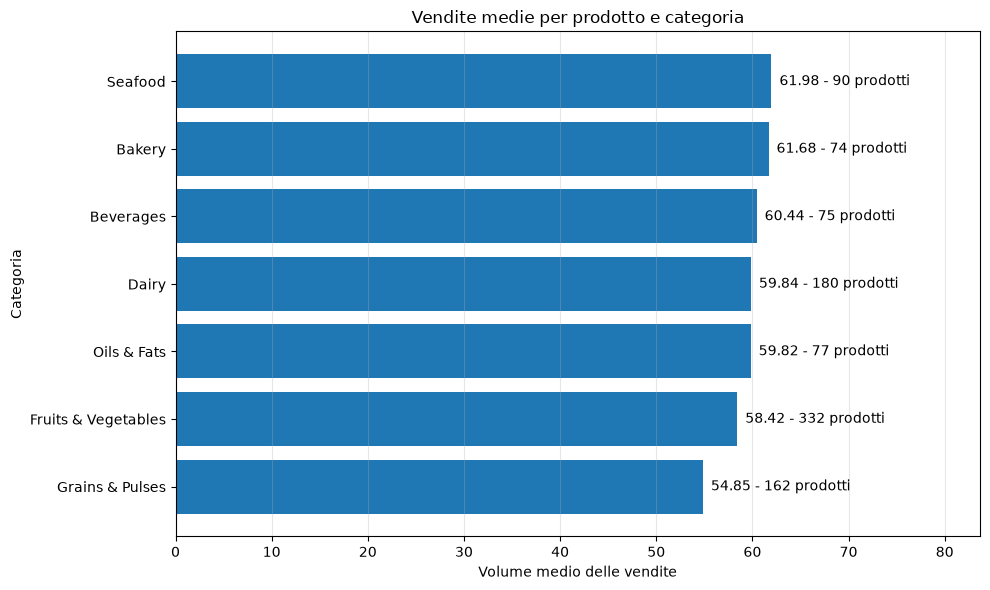

In [44]:
# Grafico delle vendite medie per prodotto in ogni categoria

dati_grafico_vendite = vendite_per_categoria.sort_values(
    by="Vendite_Medie",
    ascending=True
)

plt.figure(figsize=(10, 6))

barre = plt.barh(
    dati_grafico_vendite["Category"],
    dati_grafico_vendite["Vendite_Medie"]
)

# Aggiunta del valore medio e del numero di prodotti accanto a ogni barra

for barra, media, numero_prodotti in zip(
    barre,
    dati_grafico_vendite["Vendite_Medie"],
    dati_grafico_vendite["Numero_Prodotti"]
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f"  {media:.2f} - {numero_prodotti} prodotti",
        va="center"
    )

plt.title("Vendite medie per prodotto e categoria")
plt.xlabel("Volume medio delle vendite")
plt.ylabel("Categoria")

plt.xlim(
    0,
    dati_grafico_vendite["Vendite_Medie"].max() * 1.35
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Considerazioni

Il confronto tra classe di domanda e stato delle scorte mostra una distribuzione abbastanza simile nei tre gruppi. I prodotti ad alta domanda non presentano una quota di riordino nettamente superiore rispetto agli altri.

Circa il 45% dei prodotti ad alta domanda risulta da riordinare, mentre la percentuale sale a circa il 49% tra i prodotti a domanda bassa. La quota di prodotti sulla soglia è invece molto limitata in tutte le classi.

## Analisi dell'indice di rotazione del magazzino

L'indice `Inventory_Turnover_Rate` esprime la frequenza con cui le scorte di un prodotto vengono utilizzate o rinnovate.

Un valore elevato indica generalmente una rotazione più rapida, mentre un valore basso può segnalare prodotti che rimangono più a lungo in magazzino.

L'analisi ha l'obiettivo di:

- esaminare la distribuzione dell'indice di rotazione;
- classificare i prodotti in rotazione bassa, media e alta;
- confrontare la rotazione tra le categorie;
- individuare prodotti con rotazione bassa e quantità elevate in stock.

In [49]:
# Visualizzazione delle statistiche dell'indice di rotazione con descrizioni

statistiche_rotazione = (
    df["Inventory_Turnover_Rate"]
    .describe()
    .round(2)
    .reset_index()
)

statistiche_rotazione.columns = [
    "Statistica",
    "Valore"
]

descrizioni_statistiche = {
    "count": "Numero di valori disponibili",
    "mean": "Rotazione media",
    "std": "Dispersione dei valori",
    "min": "Valore minimo",
    "25%": "Primo quartile",
    "50%": "Mediana",
    "75%": "Terzo quartile",
    "max": "Valore massimo"
}

statistiche_rotazione["Descrizione"] = (
    statistiche_rotazione["Statistica"]
    .map(descrizioni_statistiche)
)

print(
    "Valori mancanti:",
    df["Inventory_Turnover_Rate"].isna().sum()
)

display(statistiche_rotazione)

Valori mancanti: 0


,Statistica,Valore,Descrizione
0,count,990.00,Numero di valori disponibili
1,mean,50.15,Rotazione media
2,std,28.80,Dispersione dei valori
3,min,1.00,Valore minimo
4,25%,25.00,Primo quartile
5,50%,50.00,Mediana
6,75%,74.75,Terzo quartile
7,max,100.00,Valore massimo


### Interpretazione delle statistiche

L'indice `Inventory_Turnover_Rate` misura la rapidità relativa con cui un prodotto viene movimentato e rinnovato in magazzino. Il dataset non specifica il periodo di riferimento né la formula utilizzata; i valori devono quindi essere impiegati soprattutto per confrontare i prodotti tra loro.

- **Count = 990:** l'indice di rotazione è disponibile per tutti i 990 prodotti analizzati.
- **Media = 50,15:** considerando tutti i prodotti, l'indice medio di rotazione è circa 50. Un prodotto con indice 70 presenta quindi una rotazione superiore alla media, mentre uno con indice 20 ruota più lentamente.
- **Deviazione standard = 28,80:** i valori sono molto dispersi intorno alla media. Nel magazzino sono presenti prodotti con rotazione molto bassa e altri con rotazione molto elevata.
- **Minimo = 1:** il prodotto meno movimentato presenta un indice pari a 1 e rappresenta uno degli articoli con la rotazione più lenta.
- **Primo quartile = 25:** il 25% dei prodotti ha un indice uguale o inferiore a 25. Questi prodotti costituiscono il gruppo a rotazione relativamente bassa.
- **Mediana = 50:** metà dei prodotti ha un indice uguale o inferiore a 50 e l'altra metà ha un indice uguale o superiore a 50.
- **Terzo quartile = 74,75:** il 25% dei prodotti con la rotazione più elevata presenta un indice superiore a 74,75.
- **Massimo = 100:** il prodotto più movimentato presenta un indice pari a 100.

Per esempio, un prodotto con indice 20 appartiene alla fascia più lenta del magazzino, uno con indice 50 si trova circa al centro della distribuzione, mentre un prodotto con indice 90 appartiene al gruppo con rotazione più elevata.

In [50]:
# Classificazione dei prodotti in base all'indice di rotazione del magazzino

soglia_rotazione_bassa = df["Inventory_Turnover_Rate"].quantile(0.25)
soglia_rotazione_alta = df["Inventory_Turnover_Rate"].quantile(0.75)

def classifica_rotazione(indice_rotazione):

    if indice_rotazione <= soglia_rotazione_bassa:
        return "Rotazione bassa"

    elif indice_rotazione <= soglia_rotazione_alta:
        return "Rotazione media"

    else:
        return "Rotazione alta"


df["Turnover_Class"] = df["Inventory_Turnover_Rate"].apply(
    classifica_rotazione
)

print("Soglia rotazione bassa:", soglia_rotazione_bassa)
print("Soglia rotazione alta:", soglia_rotazione_alta)

colonne_controllo_rotazione = [
    "Product_ID",
    "Product_Name",
    "Inventory_Turnover_Rate",
    "Turnover_Class"
]

display(df[colonne_controllo_rotazione].head(10))

Soglia rotazione bassa: 25.0
Soglia rotazione alta: 74.75


,Product_ID,Product_Name,Inventory_Turnover_Rate,Turnover_Class
0,29-205-1132,Sushi Rice,19,Rotazione bassa
1,40-681-9981,Arabica Coffee,1,Rotazione bassa
2,06-955-3428,Black Rice,34,Rotazione media
3,71-594-6552,Long Grain Rice,99,Rotazione alta
4,57-437-1828,Plum,25,Rotazione bassa
5,21-120-6238,All-Purpose Flour,62,Rotazione media
6,71-516-1996,Corn Oil,13,Rotazione bassa
7,39-629-5554,Egg (Goose),91,Rotazione alta
8,66-268-8345,Greek Yogurt,90,Rotazione alta
9,46-452-9419,Egg (Duck),69,Rotazione media


In [51]:
# Calcolo del numero e della percentuale di prodotti per classe di rotazione

distribuzione_rotazione = (
    df["Turnover_Class"]
    .value_counts()
    .reindex([
        "Rotazione bassa",
        "Rotazione media",
        "Rotazione alta"
    ])
    .reset_index()
)

distribuzione_rotazione.columns = [
    "Classe_Rotazione",
    "Numero_Prodotti"
]

distribuzione_rotazione["Percentuale"] = (
    distribuzione_rotazione["Numero_Prodotti"]
    / len(df)
    * 100
).round(2)

display(distribuzione_rotazione)

,Classe_Rotazione,Numero_Prodotti,Percentuale
0,Rotazione bassa,251,25.35
1,Rotazione media,491,49.60
2,Rotazione alta,248,25.05


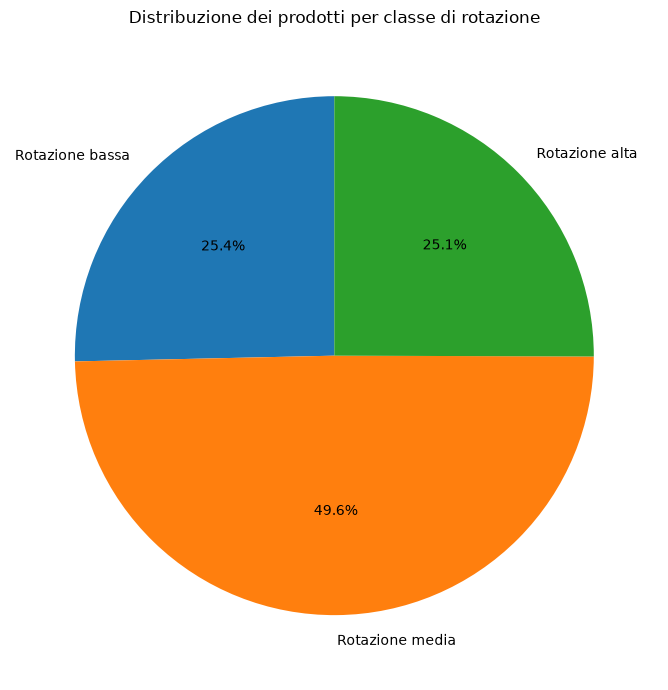

In [52]:
# Grafico a torta della distribuzione dei prodotti per classe di rotazione

conteggio_rotazione = (
    df["Turnover_Class"]
    .value_counts()
    .reindex([
        "Rotazione bassa",
        "Rotazione media",
        "Rotazione alta"
    ])
)

conteggio_rotazione.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    figsize=(7, 7)
)

plt.title("Distribuzione dei prodotti per classe di rotazione")
plt.ylabel("")
plt.tight_layout()

plt.show()

### Considerazioni

Il grafico mostra che circa metà dei prodotti appartiene alla classe di rotazione media, mentre le classi di rotazione bassa e alta comprendono ciascuna circa un quarto del catalogo.

Questa distribuzione deriva dall'utilizzo del primo e del terzo quartile come soglie di classificazione. La classe di rotazione bassa identifica i prodotti relativamente meno movimentati, mentre quella alta raccoglie gli articoli con la rotazione più elevata rispetto al resto del dataset.

## Analisi del rischio di obsolescenza

Il rischio di obsolescenza viene stimato combinando la classe di domanda e la classe di rotazione del prodotto.

Un prodotto con domanda bassa e rotazione bassa può rimanere più a lungo in magazzino e presenta quindi un rischio gestionale maggiore. Un prodotto con una sola delle due condizioni viene classificato con rischio medio, mentre gli altri prodotti vengono associati a un rischio basso.

La classificazione rappresenta un indicatore operativo relativo al dataset e non una previsione certa dell'effettiva obsolescenza.

Il valore economico dello stock non viene utilizzato per determinare il livello di rischio: verrà invece impiegato per quantificare il capitale associato ai prodotti appartenenti alle diverse classi.

### Limite dell'analisi delle scadenze

Il dataset contiene le colonne `Date_Received` ed `Expiration_Date`, ma non presenta un identificativo del lotto.

Poiché `Product_ID` identifica il prodotto e non il singolo lotto, non è possibile verificare che la data di ricezione e la data di scadenza appartengano alla stessa fornitura.

Sono inoltre presenti numerose righe nelle quali la data di scadenza precede la data di ricezione. Per questo motivo non viene calcolata una durata commerciale del prodotto e le date vengono considerate principalmente come elemento di controllo della qualità dei dati.

In [53]:
# Classificazione del rischio di obsolescenza in base a domanda e rotazione

def classifica_rischio_obsolescenza(riga):

    domanda_bassa = riga["Demand_Class"] == "Domanda bassa"
    rotazione_bassa = riga["Turnover_Class"] == "Rotazione bassa"

    if domanda_bassa and rotazione_bassa:
        return "Rischio alto"

    elif domanda_bassa or rotazione_bassa:
        return "Rischio medio"

    else:
        return "Rischio basso"


df["Obsolescence_Risk"] = df.apply(
    classifica_rischio_obsolescenza,
    axis=1
)

colonne_controllo_obsolescenza = [
    "Product_ID",
    "Product_Name",
    "Demand_Class",
    "Turnover_Class",
    "Inventory_Value",
    "Obsolescence_Risk"
]

display(
    df[colonne_controllo_obsolescenza].head(10)
)

,Product_ID,Product_Name,Demand_Class,Turnover_Class,Inventory_Value,Obsolescence_Risk
0,29-205-1132,Sushi Rice,Domanda bassa,Rotazione bassa,99.00,Rischio alto
1,40-681-9981,Arabica Coffee,Domanda alta,Rotazione bassa,900.00,Rischio medio
2,06-955-3428,Black Rice,Domanda bassa,Rotazione media,180.00,Rischio medio
3,71-594-6552,Long Grain Rice,Domanda alta,Rotazione alta,18.00,Rischio basso
4,57-437-1828,Plum,Domanda media,Rotazione bassa,148.00,Rischio medio
5,21-120-6238,All-Purpose Flour,Domanda bassa,Rotazione media,96.25,Rischio medio
6,71-516-1996,Corn Oil,Domanda media,Rotazione bassa,240.00,Rischio medio
7,39-629-5554,Egg (Goose),Domanda bassa,Rotazione alta,110.00,Rischio medio
8,66-268-8345,Greek Yogurt,Domanda media,Rotazione alta,273.00,Rischio basso
9,46-452-9419,Egg (Duck),Domanda bassa,Rotazione media,43.00,Rischio medio


In [54]:
# Controllo finale delle feature create nel dataset

feature_create = [
    "Product_Label",
    "Supply_Status",
    "Stock_Gap",
    "Inventory_Value",
    "Estimated_Reorder_Cost",
    "Units_To_Reorder_Level",
    "Stock_Reorder_Ratio",
    "Reorder_Needed_Flag",
    "Reorder_Cost_Required",
    "Backordered_Flag",
    "Demand_Class",
    "Turnover_Class",
    "Obsolescence_Risk"
]

feature_mancanti = [
    colonna
    for colonna in feature_create
    if colonna not in df.columns
]

print("Numero di righe:", len(df))
print("Numero totale di colonne:", len(df.columns))
print("Feature previste:", len(feature_create))

if len(feature_mancanti) == 0:
    print("Controllo completato: tutte le feature sono presenti.")
else:
    print("Feature mancanti:", feature_mancanti)

print("\nValori mancanti nelle nuove feature:")

display(
    df[feature_create]
    .isna()
    .sum()
    .rename("Valori_mancanti")
)

display(
    df[
        [
            "Product_ID",
            "Product_Name",
            "Supply_Status",
            "Demand_Class",
            "Turnover_Class",
            "Obsolescence_Risk",
            "Inventory_Value"
        ]
    ].head(10)
)

Numero di righe: 990
Numero totale di colonne: 29
Feature previste: 13
Controllo completato: tutte le feature sono presenti.

Valori mancanti nelle nuove feature:


Product_Label             0
Supply_Status             0
Stock_Gap                 0
Inventory_Value           0
Estimated_Reorder_Cost    0
Units_To_Reorder_Level    0
Stock_Reorder_Ratio       0
Reorder_Needed_Flag       0
Reorder_Cost_Required     0
Backordered_Flag          0
Demand_Class              0
Turnover_Class            0
Obsolescence_Risk         0
Name: Valori_mancanti, dtype: int64

,Product_ID,Product_Name,Supply_Status,Demand_Class,Turnover_Class,Obsolescence_Risk,Inventory_Value
0,29-205-1132,Sushi Rice,Da riordinare,Domanda bassa,Rotazione bassa,Rischio alto,99.00
1,40-681-9981,Arabica Coffee,Da riordinare,Domanda alta,Rotazione bassa,Rischio medio,900.00
2,06-955-3428,Black Rice,Da riordinare,Domanda bassa,Rotazione media,Rischio medio,180.00
3,71-594-6552,Long Grain Rice,Da riordinare,Domanda alta,Rotazione alta,Rischio basso,18.00
4,57-437-1828,Plum,Scorta sufficiente,Domanda media,Rotazione bassa,Rischio medio,148.00
5,21-120-6238,All-Purpose Flour,Scorta sufficiente,Domanda bassa,Rotazione media,Rischio medio,96.25
6,71-516-1996,Corn Oil,Scorta sufficiente,Domanda media,Rotazione bassa,Rischio medio,240.00
7,39-629-5554,Egg (Goose),Da riordinare,Domanda bassa,Rotazione alta,Rischio medio,110.00
8,66-268-8345,Greek Yogurt,Scorta sufficiente,Domanda media,Rotazione alta,Rischio basso,273.00
9,46-452-9419,Egg (Duck),Scorta sufficiente,Domanda bassa,Rotazione media,Rischio medio,43.00


In [55]:
# Esportazione del dataset arricchito nel file dataset_finale.csv

file_output = Path("dataset_finale.csv")

df.to_csv(
    file_output,
    index=False,
    date_format="%Y-%m-%d",
    encoding="utf-8-sig"
)

print("Esportazione completata correttamente.")
print("Nome del file:", file_output.name)
print("Percorso completo:", file_output.resolve())
print("Righe esportate:", len(df))
print("Colonne esportate:", len(df.columns))

Esportazione completata correttamente.
Nome del file: dataset_finale.csv
Percorso completo: C:\Users\mace\OneDrive\python\installazione1\project work\Analisi dati di magazzino\dataset_finale.csv
Righe esportate: 990
Colonne esportate: 29


## Conclusione

Il dataset è stato sottoposto a controlli di qualità, analisi esplorativa e feature engineering.

Sono state create nuove variabili relative allo stato delle scorte, al valore economico del magazzino, alle necessità di riordino, alla domanda, alla rotazione e al rischio gestionale di obsolescenza.

Le date di ricezione e scadenza non sono state utilizzate per calcolare la durata dei lotti, poiché il dataset non contiene un identificativo univoco del lotto e presenta alcune incoerenze temporali.

Il risultato finale è stato esportato nel file `dataset_finale.csv`, pronto per essere utilizzato in un report.